In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\A\OneDrive\Desktop\project ds\AI_Impact_on_Jobs_2030_PRO.csv')
df.head(10)

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030
0,Security Guard,45795,28,Master's,0.18,1.28,0.85
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05
2,Construction Worker,146216,2,High School,0.86,1.18,0.81
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64
5,AI Engineer,92592,11,Master's,0.29,0.51,0.10
6,Mechanic,107373,23,PhD,0.67,1.09,0.41
7,Teacher,53419,12,High School,0.20,1.40,0.17
8,HR Specialist,139225,12,Master's,0.30,0.61,0.48
9,Customer Support,85016,2,High School,0.01,1.01,0.80


In [4]:
df["risk_score"] = 0.6 * df["Automation_Probability_2030"] + 0.4 * df["AI_Exposure_Index"]

df["Risk_Category"] = pd.cut(
    df["risk_score"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)


In [5]:
df

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,risk_score,Risk_Category
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,0.582,Medium
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,0.278,Low
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,0.830,High
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,0.516,Medium
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,0.592,Medium
...,...,...,...,...,...,...,...,...,...
2995,Doctor,111319,6,Bachelor's,0.24,1.18,0.20,0.216,Low
2996,UX Researcher,44363,29,PhD,0.65,0.74,0.35,0.470,Medium
2997,Data Scientist,61325,23,Master's,0.64,0.94,0.39,0.490,Medium
2998,Graphic Designer,110296,7,PhD,0.95,1.23,0.46,0.656,High


In [6]:
df.drop("Tech_Growth_Factor" , axis=1 , inplace=True)
df

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Automation_Probability_2030,risk_score,Risk_Category
0,Security Guard,45795,28,Master's,0.18,0.85,0.582,Medium
1,Research Scientist,133355,20,PhD,0.62,0.05,0.278,Low
2,Construction Worker,146216,2,High School,0.86,0.81,0.830,High
3,Software Engineer,136530,13,PhD,0.39,0.60,0.516,Medium
4,Financial Analyst,70397,22,High School,0.52,0.64,0.592,Medium
...,...,...,...,...,...,...,...,...
2995,Doctor,111319,6,Bachelor's,0.24,0.20,0.216,Low
2996,UX Researcher,44363,29,PhD,0.65,0.35,0.470,Medium
2997,Data Scientist,61325,23,Master's,0.64,0.39,0.490,Medium
2998,Graphic Designer,110296,7,PhD,0.95,0.46,0.656,High


In [7]:
df.isnull().sum()

Job_Title                      0
Average_Salary                 0
Years_Experience               0
Education_Level                0
AI_Exposure_Index              0
Automation_Probability_2030    0
risk_score                     0
Risk_Category                  0
dtype: int64

In [8]:
df.describe()

,Average_Salary,Years_Experience,AI_Exposure_Index,Automation_Probability_2030,risk_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,89372.279000,14.677667,0.501283,0.501503,0.501415
std,34608.088767,8.739788,0.284004,0.247881,0.188440
min,30030.000000,0.000000,0.000000,0.050000,0.036000
25%,58640.000000,7.000000,0.260000,0.310000,0.367500
50%,89318.000000,15.000000,0.500000,0.500000,0.500000
75%,119086.500000,22.000000,0.740000,0.700000,0.636500
max,149798.000000,29.000000,1.000000,0.950000,0.954000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Job_Title                    3000 non-null   object  
 1   Average_Salary               3000 non-null   int64   
 2   Years_Experience             3000 non-null   int64   
 3   Education_Level              3000 non-null   object  
 4   AI_Exposure_Index            3000 non-null   float64 
 5   Automation_Probability_2030  3000 non-null   float64 
 6   risk_score                   3000 non-null   float64 
 7   Risk_Category                3000 non-null   category
dtypes: category(1), float64(3), int64(2), object(2)
memory usage: 167.2+ KB


In [10]:
df.duplicated().sum()

0

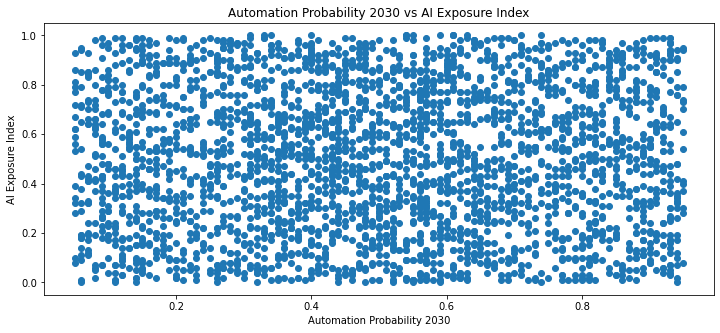

In [14]:
x = df['Automation_Probability_2030']
y = df['AI_Exposure_Index']

plt.figure(figsize=(12,5))
plt.scatter(x, y)
plt.title("Automation Probability 2030 vs AI Exposure Index")
plt.xlabel("Automation Probability 2030")
plt.ylabel("AI Exposure Index")
plt.show()

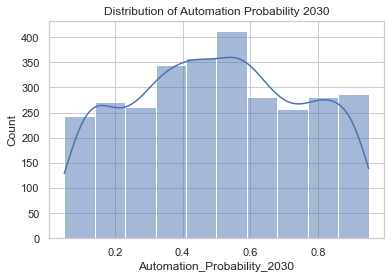

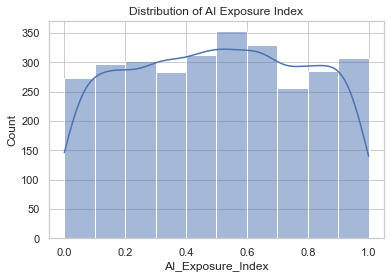

In [79]:
plt.figure()
sns.histplot(df['Automation_Probability_2030'], bins=10, kde=True)
plt.title("Distribution of Automation Probability 2030")
plt.show()

plt.figure()
sns.histplot(df['AI_Exposure_Index'], bins=10, kde=True)
plt.title("Distribution of AI Exposure Index")
plt.show()

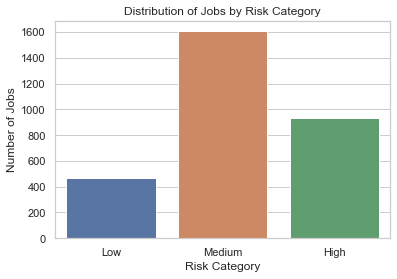

In [80]:
plt.figure()
sns.countplot(x='Risk_Category', data=df)
plt.title("Distribution of Jobs by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Jobs")
plt.show()

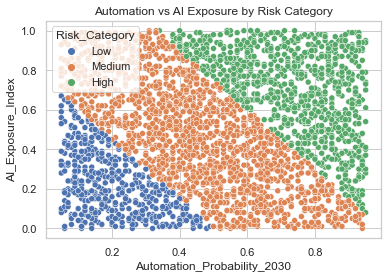

In [81]:
plt.figure()
sns.scatterplot(
    x='Automation_Probability_2030',
    y='AI_Exposure_Index',
    hue='Risk_Category',
    data=df
)
plt.title("Automation vs AI Exposure by Risk Category")
plt.show()